# Importation des bibliotheques

In [4]:
import pandas as pd
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder


In [6]:
data=pd.read_csv("Datas/train.csv", sep=",")

In [7]:
# Drop the 'New_Price' column
data.drop(columns=['New_Price'], inplace=True)


In [8]:
data.dropna()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,4.75
6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,4.00
6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,2.90
6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,2.65


In [9]:
features = data[['Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']]
prix = data.Price

In [10]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               6019 non-null   int64  
 1   Kilometers_Driven  6019 non-null   int64  
 2   Fuel_Type          6019 non-null   object 
 3   Transmission       6019 non-null   object 
 4   Owner_Type         6019 non-null   object 
 5   Mileage            6017 non-null   object 
 6   Engine             5983 non-null   object 
 7   Power              5983 non-null   object 
 8   Seats              5977 non-null   float64
dtypes: float64(1), int64(2), object(6)
memory usage: 423.3+ KB


In [11]:
features.head()

,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0
1,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0
2,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0
3,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0
4,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0


In [12]:
features.Owner_Type.unique()

array(['First', 'Second', 'Fourth & Above', 'Third'], dtype=object)

In [13]:
def extract_numeric(value):
    if isinstance(value, str):
        value = ''.join([c for c in value if c.isdigit() or c == '.'])
        return float(value) if value else None
    return value

features["Mileage"] = features["Mileage"].apply(extract_numeric)
features["Engine"] = features["Engine"].apply(extract_numeric)
features["Power"] = features["Power"].apply(extract_numeric)

C:\Users\Marwane\AppData\Local\Temp\ipykernel_16960\2607555603.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Mileage"] = features["Mileage"].apply(extract_numeric)
C:\Users\Marwane\AppData\Local\Temp\ipykernel_16960\2607555603.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Engine"] = features["Engine"].apply(extract_numeric)
C:\Users\Marwane\AppData\Local\Temp\ipykernel_16960\2607555603.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

In [14]:
# Sélectionner les colonnes catégorielles
colonnes_categorielle = ["Fuel_Type","Transmission","Owner_Type"]

# Initialiser le OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' pour éviter la colinéarité

# Transformer les colonnes catégorielles
encoded_array = encoder.fit_transform(features[colonnes_categorielle])

# Convertir en DataFrame avec noms explicites des colonnes
encoded_data = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(colonnes_categorielle))

# Supprimer les colonnes catégorielles originales et concaténer le DataFrame encodé
features = features.drop(columns=colonnes_categorielle).join(encoded_data)

# Afficher le DataFrame final
features.head()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,2010,72000,26.60,998.0,58.16,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2015,41000,19.67,1582.0,126.20,5.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2011,46000,18.20,1199.0,88.70,5.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,2012,87000,20.77,1248.0,88.76,7.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2013,40670,15.20,1968.0,140.80,5.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       6019 non-null   int64  
 1   Kilometers_Driven          6019 non-null   int64  
 2   Mileage                    6017 non-null   float64
 3   Engine                     5983 non-null   float64
 4   Power                      5876 non-null   float64
 5   Seats                      5977 non-null   float64
 6   Fuel_Type_Diesel           6019 non-null   float64
 7   Fuel_Type_Electric         6019 non-null   float64
 8   Fuel_Type_LPG              6019 non-null   float64
 9   Fuel_Type_Petrol           6019 non-null   float64
 10  Transmission_Manual        6019 non-null   float64
 11  Owner_Type_Fourth & Above  6019 non-null   float64
 12  Owner_Type_Second          6019 non-null   float64
 13  Owner_Type_Third           6019 non-null   float

In [16]:
# X = pd.get_dummies(features, drop_first=True)
X=features
y=prix

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

# Initialisation et entraînement du modèle XGBoost
model = XGBRegressor(n_estimators=60, max_depth=4, random_state=42)
model.fit(X_train, np.log(y_train))  # On applique une transformation logarithmique sur la cible

# Prédictions sur les ensembles d'entraînement et de test
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Évaluation du modèle
train_r2 = r2_score(np.log(y_train), y_train_pred)
test_r2 = r2_score(np.log(y_test), y_test_pred)
train_rmse = np.sqrt(mean_squared_error(np.log(y_train), y_train_pred))
test_rmse = np.sqrt(mean_squared_error(np.log(y_test), y_test_pred))

# Affichage des résultats
print(f"R2 Score (train) : {train_r2:.4f}")
print(f"R2 Score (test) : {test_r2:.4f}")
print(f"RMSE (train) : {train_rmse:.4f}")
print(f"RMSE (test) : {test_rmse:.4f}")


R2 Score (train) : 0.9506
R2 Score (test) : 0.9089
RMSE (train) : 0.1938
RMSE (test) : 0.2662


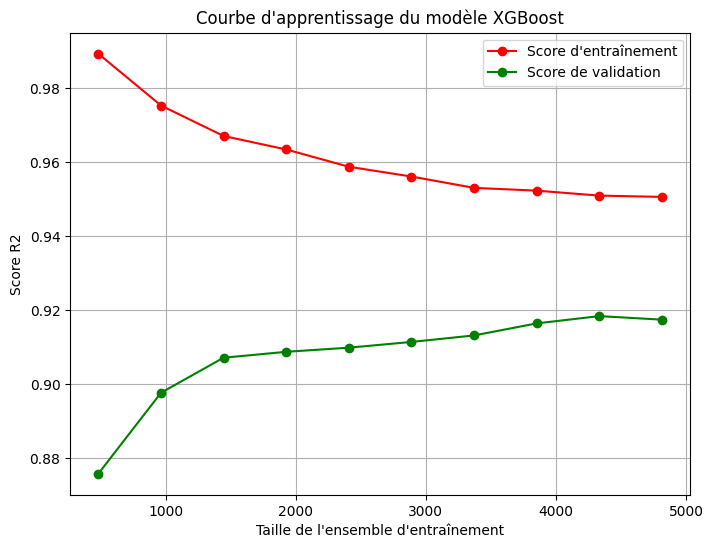

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Générer les courbes d'apprentissage
def plot_learning_curve(estimator, X, y, cv=5, n_jobs=-1):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, np.log(y), cv=cv, scoring='r2', n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score d'entraînement")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score de validation")
    
    plt.xlabel("Taille de l'ensemble d'entraînement")
    plt.ylabel("Score R2")
    plt.title("Courbe d'apprentissage du modèle XGBoost")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialisation et entraînement du modèle XGBoost
model = XGBRegressor(n_estimators=60, max_depth=4, random_state=42)
model.fit(X_train, np.log(y_train))

# Tracer la courbe d'apprentissage
plot_learning_curve(model, X, y)
